# Частина друга: Аналіз файлів

In [38]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

##### Прочитайте файл 2017_jun_final.csv за допомогою методу read_csv
##### Прочитайте отриману таблицю, використовуючи метод head

In [2]:
sheet_id = "1bclX5PbqE8zR1-wOSM3ZTFa53sIC7RXqwty7Abmw9yQ"
gid = "1724592523"
url = f"https://docs.google.com/spreadsheets/d/{sheet_id}/export?format=csv&gid={gid}"

response = pd.read_csv(url)
df = response
df.head()

,N,Посада,Мова програмування,Спеціалізація,Загальний досвід роботи,Досвід роботи на поточному місці,Зарплата на місяць,Зміна зарплати за 12 місяців,Місто,Розмір компанії,...,Ще студент,Рівень англійської,Предметна область,Дата заповнення,User.Agent,exp,current_job_exp,salary,Валюта,cls
0,1,Junior QA engineer,NaN,Manual QA,0.5,0.5,400,0,Харків,до 10 осіб,...,True,Pre-intermediate (нище середнього),"iOS,eCommerce",12/06/2017 12:38:08,Mozilla/5.0 (Windows NT 10.0; Win64; x64) Appl...,0.5,0.5,400,NaN,QA
1,2,Junior QA engineer,NaN,Manual QA,менше 3 місяців,менше 3 місяців,430,130,Харків,більше 1000 осіб,...,True,Upper-Intermediate (вище середнього),Веб-розробка,12/06/2017 12:42:51,Mozilla/5.0 (iPad; CPU OS 10_2_1 like Mac OS X...,0.0,0.0,430,NaN,QA
2,3,Software Engineer,C#/.NET,NaN,4,1,2500,800,Київ,до 1000 осіб,...,False,Intermediate (середній),"Веб-розробка,Корпоративні системи",12/06/2017 13:02:47,Mozilla/5.0 (Windows NT 10.0; Win64; x64) Appl...,4.0,1.0,2500,NaN,DEV
3,4,Software Engineer,JavaScript,NaN,5,4,2000,400,Одеса,до 200 осіб,...,False,Pre-intermediate (нище середнього),"Desktop Applications,Веб-розробка",12/06/2017 13:03:01,Mozilla/5.0 (Windows NT 6.1; Win64; x64) Apple...,5.0,4.0,2000,NaN,DEV
4,5,Senior Software Engineer,JavaScript,NaN,10 і більше років,0.5,4500,500,Інше,до 10 осіб,...,False,Intermediate (середній),"Desktop Applications,Веб-розробка",12/06/2017 13:03:47,Mozilla/5.0 (iPhone; CPU iPhone OS 10_3_2 like...,10.0,0.5,4500,NaN,DEV


##### Визначте розмір таблиці за допомогою методу shape

In [3]:
df.shape

(8704, 25)

##### Визначте типи всіх стовпців за допомогою dataframe.dtypes

In [4]:
df.dtypes

N                                     int64
Посада                                  str
Мова програмування                      str
Спеціалізація                           str
Загальний досвід роботи                 str
Досвід роботи на поточному місці        str
Зарплата на місяць                    int64
Зміна зарплати за 12 місяців          int64
Місто                                   str
Розмір компанії                         str
Тип компанії                            str
Стать                                   str
Вік                                   int64
Освіта                                  str
Університет                             str
Ще студент                             bool
Рівень англійської                      str
Предметна область                       str
Дата заповнення                         str
User.Agent                              str
exp                                 float64
current_job_exp                     float64
salary                          

##### Порахуйте, яка частка пропусків міститься в кожній колонці (використовуйте методи isnull та sum)

In [5]:
nulls_table = df.isna().sum() / len(df)
nulls_table

N                                   0.000000
Посада                              0.000000
Мова програмування                  0.442325
Спеціалізація                       0.829389
Загальний досвід роботи             0.000000
Досвід роботи на поточному місці    0.000000
Зарплата на місяць                  0.000000
Зміна зарплати за 12 місяців        0.000000
Місто                               0.000000
Розмір компанії                     0.000000
Тип компанії                        0.000000
Стать                               0.000000
Вік                                 0.000000
Освіта                              0.000000
Університет                         0.041131
Ще студент                          0.000000
Рівень англійської                  0.000000
Предметна область                   0.025620
Дата заповнення                     0.000000
User.Agent                          0.000000
exp                                 0.000000
current_job_exp                     0.000000
salary    

##### Видаліть усі стовпці з пропусками, крім стовпця "Мова програмування"

In [6]:
cols_marked_for_del = nulls_table[nulls_table>0].index.tolist()
cols_marked_for_del.remove("Мова програмування") if "Мова програмування" in cols_marked_for_del else cols_marked_for_del
print(f"df.shape = {df.shape}")
df = df.drop(columns=cols_marked_for_del)
print(f"deleted {len(cols_marked_for_del)} cols: {cols_marked_for_del}")
print(f"df.shape = {df.shape}")

df.shape = (8704, 25)
deleted 5 cols: ['Спеціалізація', 'Університет', 'Предметна область', 'Валюта', 'cls']
df.shape = (8704, 20)


##### Знову порахуйте, яка частка пропусків міститься в кожній колонці і переконайтеся, що залишився тільки стовпець "Мова.програмування"

In [7]:
nulls_table = df.isna().sum() / len(df)
print(f"Are all columns from 'cols_marked_for_del' deleted? {not any(item in cols_marked_for_del for item in df.columns)}")
nulls_table

Are all columns from 'cols_marked_for_del' deleted? True


N                                   0.000000
Посада                              0.000000
Мова програмування                  0.442325
Загальний досвід роботи             0.000000
Досвід роботи на поточному місці    0.000000
Зарплата на місяць                  0.000000
Зміна зарплати за 12 місяців        0.000000
Місто                               0.000000
Розмір компанії                     0.000000
Тип компанії                        0.000000
Стать                               0.000000
Вік                                 0.000000
Освіта                              0.000000
Ще студент                          0.000000
Рівень англійської                  0.000000
Дата заповнення                     0.000000
User.Agent                          0.000000
exp                                 0.000000
current_job_exp                     0.000000
salary                              0.000000
dtype: float64

##### Видаліть усі рядки у вихідній таблиці за допомогою методу dropna
#####  Визначте новий розмір таблиці за допомогою методу shapea

In [8]:
print(f"df.shape = {df.shape}")
print(f"Rows with missing values: {df.isna().sum().sum()}")
df = df.dropna(how="any")
print("deleted")
print(f"df.shape = {df.shape}")

df.shape = (8704, 20)
Rows with missing values: 3850
deleted
df.shape = (4854, 20)


##### Створіть нову таблицю python_data, в якій будуть тільки рядки зі спеціалістами, які вказали мову програмування Python
##### Визначте розмір таблиці python_data за допомогою методу shape

In [9]:
python_data = df[df["Мова програмування"] == "Python"]
print(f"shape = {python_data.shape}")
python_data.head(3)

shape = (207, 20)


,N,Посада,Мова програмування,Загальний досвід роботи,Досвід роботи на поточному місці,Зарплата на місяць,Зміна зарплати за 12 місяців,Місто,Розмір компанії,Тип компанії,Стать,Вік,Освіта,Ще студент,Рівень англійської,Дата заповнення,User.Agent,exp,current_job_exp,salary
12,13,Software Engineer,Python,1,менше 3 місяців,800,200,Київ,до 50 осіб,Аутсорсингова,чоловіча,26,Вища,False,Pre-intermediate (нище середнього),12/06/2017 13:05:54,Mozilla/5.0 (Windows NT 6.1; Win64; x64) Apple...,1.0,0.0,800
68,69,Software Engineer,Python,1.5,0.5,900,900,Київ,до 10 осіб,Стартап,чоловіча,21,Неповна Вища,True,Upper-Intermediate (вище середнього),12/06/2017 13:11:17,Mozilla/5.0 (Windows NT 10.0; Win64; x64) Appl...,1.5,0.5,900
87,88,Junior Software Engineer,Python,0.5,0.5,600,0,Київ,до 10 осіб,Аутсорсингова,чоловіча,19,Неповна Вища,True,Upper-Intermediate (вище середнього),12/06/2017 13:12:25,Mozilla/5.0 (X11; Linux x86_64) AppleWebKit/53...,0.5,0.5,600


##### Використовуючи метод groupby, виконайте групування за стовпчиком "Посада"

In [10]:
python_data.groupby(by="Посада")[["Зарплата на місяць","Зміна зарплати за 12 місяців","Вік","exp", "current_job_exp", "salary"]].mean()

,Зарплата на місяць,Зміна зарплати за 12 місяців,Вік,exp,current_job_exp,salary
Посада,,,,,,
Junior Software Engineer,560.841270,181.031746,24.174603,0.876984,0.523810,560.841270
Senior Software Engineer,3387.096774,431.612903,29.064516,6.677419,1.556452,3387.096774
Software Engineer,1799.070000,479.830000,26.630000,3.180000,1.127500,1799.070000
System Architect,4000.000000,0.000000,35.500000,10.000000,1.125000,4000.000000
Technical Lead,3165.909091,455.000000,30.090909,7.090909,3.386364,3165.909091


##### Створіть новий DataFrame, де для згрупованих даних за стовпчиком "Посада", виконайте агрегацію даних за допомогою методу agg і знайдіть мінімальне та максимальне значення у стовпчику "Зарплата.в.місяць"

In [11]:
new_df = python_data.groupby(by="Посада")["Зарплата на місяць"].agg(["min", "max"])
new_df

,min,max
Посада,,
Junior Software Engineer,100,1250
Senior Software Engineer,1300,9200
Software Engineer,500,5400
System Architect,3000,5000
Technical Lead,1425,6200


##### Створіть функцію fill_avg_salary, яка повертатиме середнє значення заробітної плати на місяць. Використовуйте її для методу apply та створіть новий стовпчик "avg"

In [12]:
# The task is unclear. Apply alters data, but it wants us to get the existing data. Assumed we need to use 'apply' as custom aggregation (doesn't make sense for 'mean')
def fill_avg_salary(x: float) -> float:
    return np.mean(x)

# Calculate the averages (this creates a Series indexed by "Посада")
avg_series = python_data.groupby("Посада")["Зарплата на місяць"].apply(fill_avg_salary)
# Map those values back to the original rows using the "Посада" column
python_data["avg"] = python_data["Посада"].map(avg_series)
python_data.head()

,N,Посада,Мова програмування,Загальний досвід роботи,Досвід роботи на поточному місці,Зарплата на місяць,Зміна зарплати за 12 місяців,Місто,Розмір компанії,Тип компанії,...,Вік,Освіта,Ще студент,Рівень англійської,Дата заповнення,User.Agent,exp,current_job_exp,salary,avg
12,13,Software Engineer,Python,1,менше 3 місяців,800,200,Київ,до 50 осіб,Аутсорсингова,...,26,Вища,False,Pre-intermediate (нище середнього),12/06/2017 13:05:54,Mozilla/5.0 (Windows NT 6.1; Win64; x64) Apple...,1.0,0.0,800,1799.07000
68,69,Software Engineer,Python,1.5,0.5,900,900,Київ,до 10 осіб,Стартап,...,21,Неповна Вища,True,Upper-Intermediate (вище середнього),12/06/2017 13:11:17,Mozilla/5.0 (Windows NT 10.0; Win64; x64) Appl...,1.5,0.5,900,1799.07000
87,88,Junior Software Engineer,Python,0.5,0.5,600,0,Київ,до 10 осіб,Аутсорсингова,...,19,Неповна Вища,True,Upper-Intermediate (вище середнього),12/06/2017 13:12:25,Mozilla/5.0 (X11; Linux x86_64) AppleWebKit/53...,0.5,0.5,600,560.84127
114,115,Junior Software Engineer,Python,1.5,0.5,685,250,Київ,до 1000 осіб,Аутсорсингова,...,21,Неповна Вища,False,Intermediate (середній),12/06/2017 13:14:52,Mozilla/5.0 (X11; Linux x86_64) AppleWebKit/53...,1.5,0.5,685,560.84127
143,144,Junior Software Engineer,Python,1,1,750,250,Київ,до 10 осіб,Аутсорсингова,...,21,Неповна Вища,True,Upper-Intermediate (вище середнього),12/06/2017 13:19:10,Mozilla/5.0 (X11; Linux x86_64) AppleWebKit/53...,1.0,1.0,750,560.84127


##### Створіть описову статистику за допомогою методу describe для нового стовпчика.

In [13]:
python_data["avg"].describe()

count     207.000000
mean     1753.937198
std       996.562606
min       560.841270
25%       560.841270
50%      1799.070000
75%      1799.070000
max      4000.000000
Name: avg, dtype: float64

##### Збережіть отриману таблицю в CSV файл

In [14]:
python_data.to_csv("python_data.csv", index=False)

## Додайте від 3 до 5 графіків функцій різного типу на ваш вибір. Задайте графікам оформлення, щоб кожен графік у своїй домашній роботі чимось відрізнявся і не був схожим на інші. Можна використовувати як matplotlib, так і seaborn.

In [ ]:
# revert to the original df
df = response
# drop meaningless columns
df = df.drop(columns=['N'])
df.head(2)

,Посада,Мова програмування,Спеціалізація,Загальний досвід роботи,Досвід роботи на поточному місці,Зарплата на місяць,Зміна зарплати за 12 місяців,Місто,Розмір компанії,Тип компанії,...,Ще студент,Рівень англійської,Предметна область,Дата заповнення,User.Agent,exp,current_job_exp,salary,Валюта,cls
0,Junior QA engineer,NaN,Manual QA,0.5,0.5,400,0,Харків,до 10 осіб,Аутсорсингова,...,True,Pre-intermediate (нище середнього),"iOS,eCommerce",12/06/2017 12:38:08,Mozilla/5.0 (Windows NT 10.0; Win64; x64) Appl...,0.5,0.5,400,NaN,QA
1,Junior QA engineer,NaN,Manual QA,менше 3 місяців,менше 3 місяців,430,130,Харків,більше 1000 осіб,Аутсорсингова,...,True,Upper-Intermediate (вище середнього),Веб-розробка,12/06/2017 12:42:51,Mozilla/5.0 (iPad; CPU OS 10_2_1 like Mac OS X...,0.0,0.0,430,NaN,QA


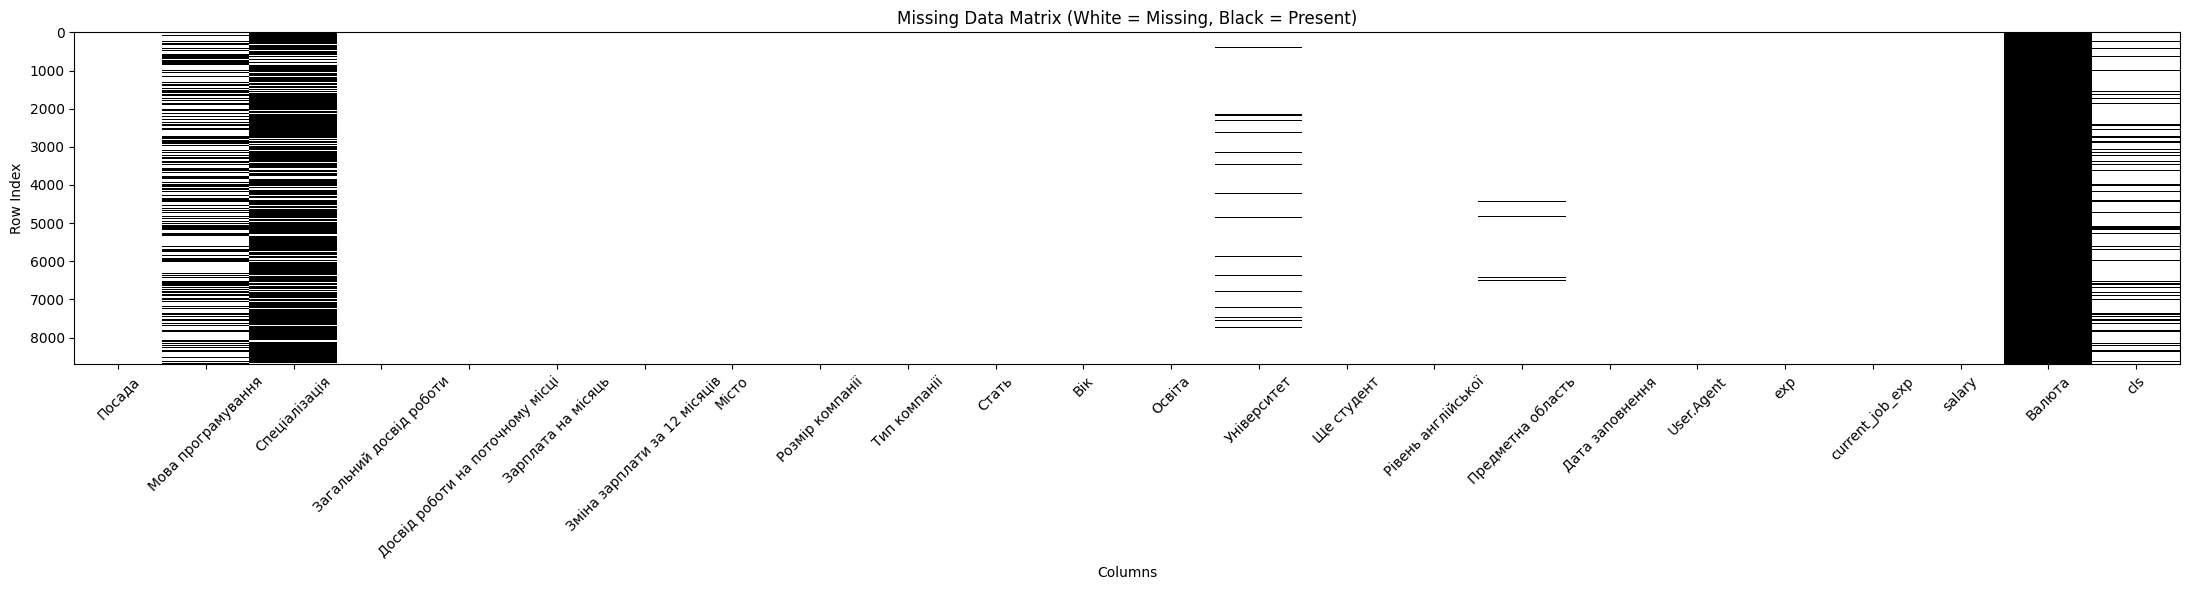

In [27]:
# Creating a visual mask: True (1) for missing, False (0) for present
plt.figure(figsize=(22, 6))
plt.imshow(df.isna(), aspect='auto', interpolation='nearest', cmap='binary')

plt.xlabel("Columns")
plt.ylabel("Row Index")
plt.xticks(range(len(df.columns)), df.columns, rotation=45)
plt.title("Missing Data Matrix (White = Missing, Black = Present)")
plt.tight_layout()
plt.show()

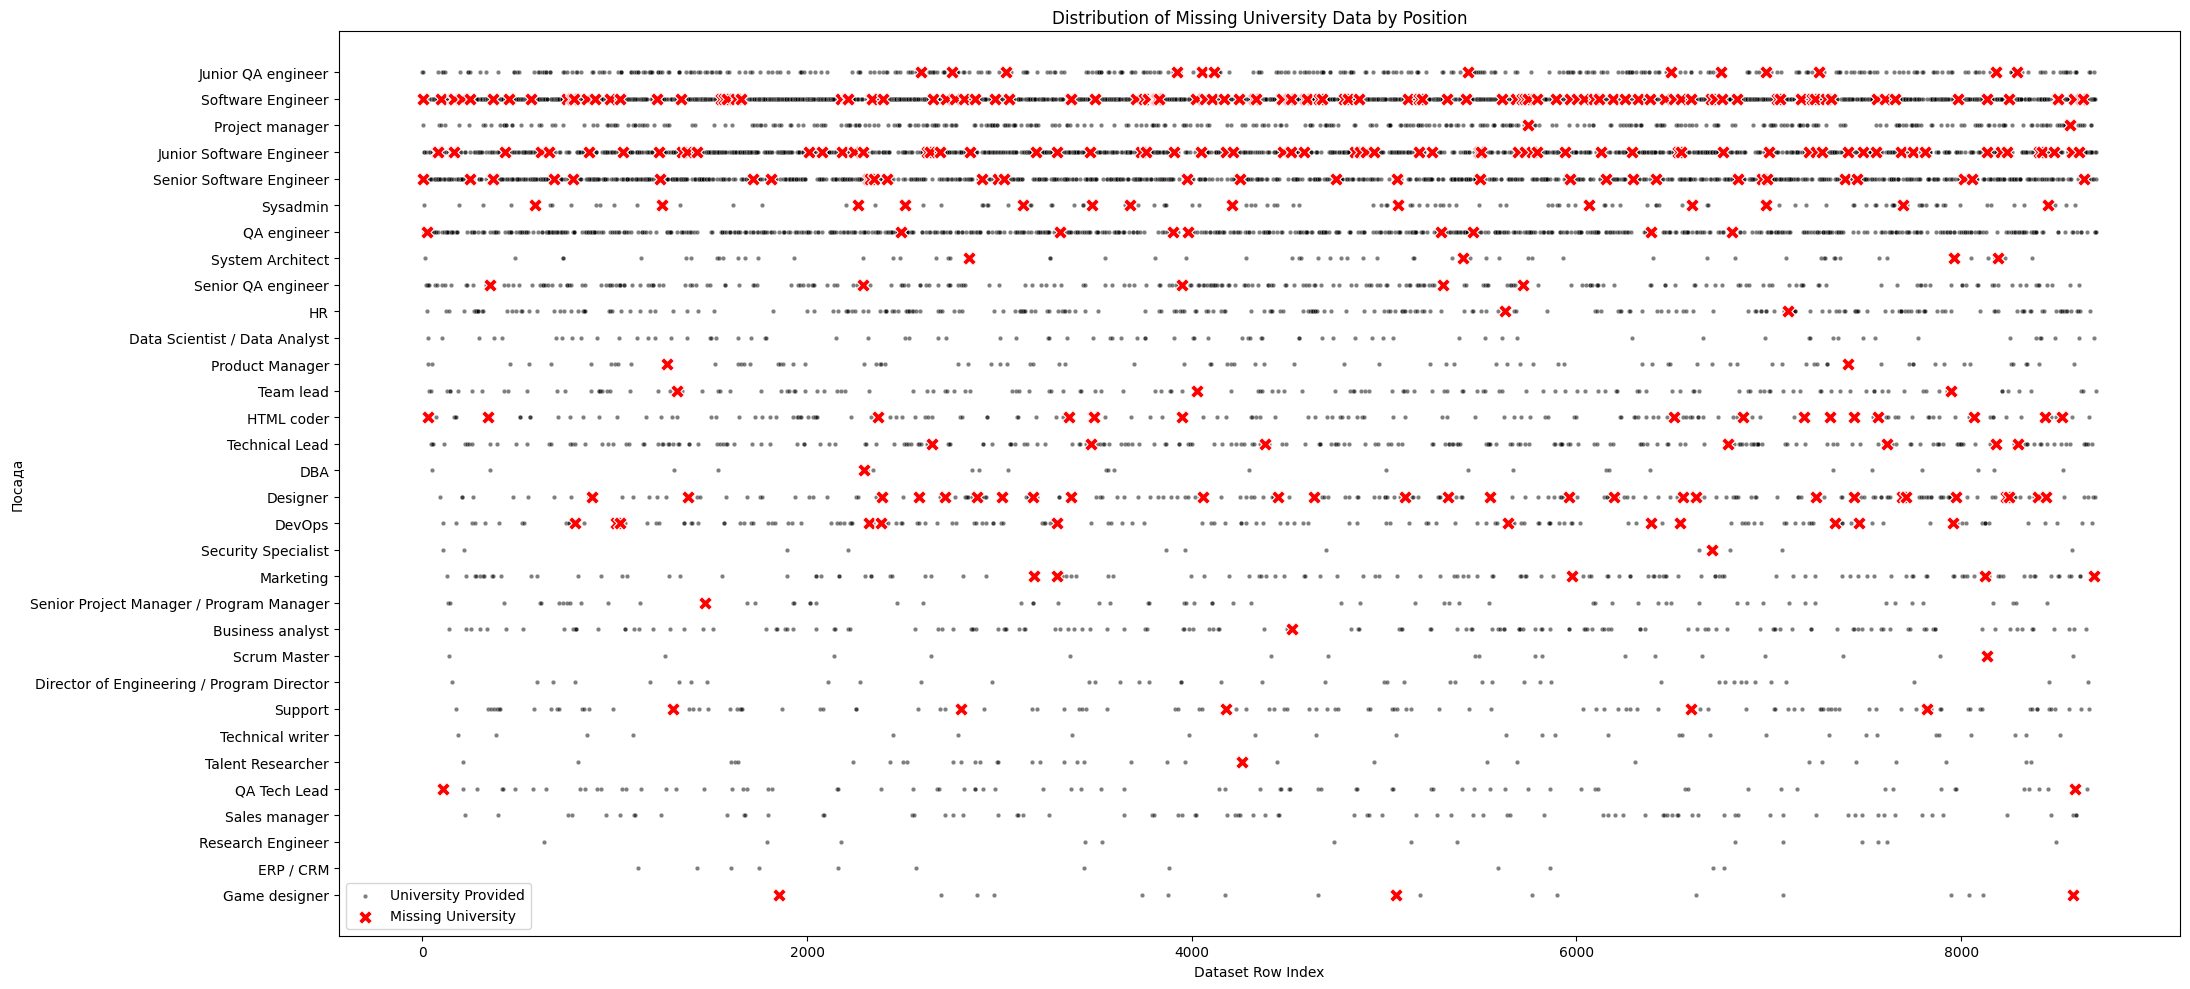

In [67]:
# 1. Create a helper column to identify missing values
df['University_specified'] = df['Університет'].isna()

plt.figure(figsize=(22, 10))

# 2. Plot "Not Nulls" first (smaller, less distracting color)
sns.scatterplot(
    data=df[df['University_specified'] == False],
    x=df[df['University_specified'] == False].index, # Use the index as X
    y='Посада',
    color='black',
    s=10,
    alpha=0.5,
    label='University Provided',
)

# 3. Plot "Nulls" on top (bright red, larger marker)
sns.scatterplot(
    data=df[df['University_specified'] == True],
    x=df[df['University_specified'] == True].index, # Use the index as X
    y='Посада',
    color='red',
    s=100,
    marker='X',
    label='Missing University',
)

plt.title("Distribution of Missing University Data by Position")
plt.xlabel("Dataset Row Index")
plt.legend()
plt.tight_layout()
plt.show()

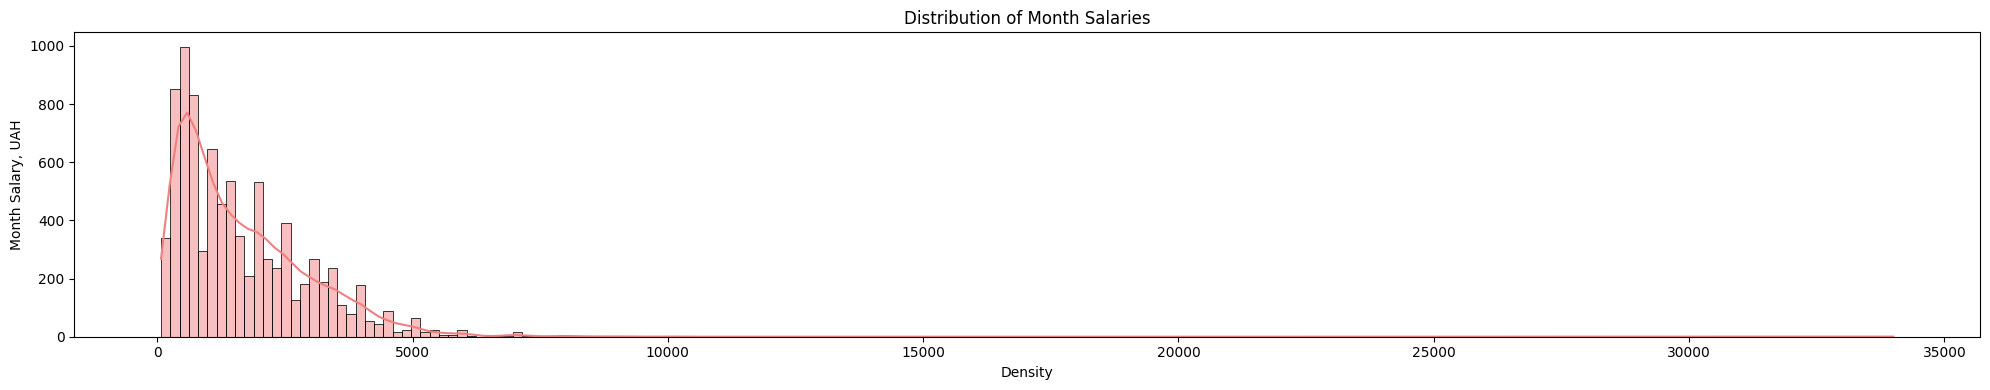

In [44]:
fig, ax = plt.subplots(figsize=(20,4))

sns.histplot(df['Зарплата на місяць'], kde=True, color='lightcoral')
plt.title('Distribution of Month Salaries')
plt.xlabel('Density')
plt.ylabel('Month Salary, UAH')
plt.tight_layout()
plt.show()